In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler

# Data Preprocessing

###  Load Dataset 

In [59]:
file_path = "ames_housing.csv" 
houses_data = pd.read_csv(file_path)
print(houses_data.head())  

   SalePrice  LotFrontage  LotArea  OverallQual  GrLivArea  TotalBsmtSF  \
0  14.467128          NaN     4044            3        690         87.0   
1  14.467785          NaN     2557            8       3783         46.0   
2  14.444119          NaN     3846            1       3777       1502.0   
3  14.466687          NaN     5348            9       2444          NaN   
4  14.322270          NaN     8980            4       3640       1542.0   

  HouseStyle CentralAir Neighborhood  
0     1.5Fin          N      Somerst  
1        NaN          N      Edwards  
2     1Story          N      OldTown  
3     1.5Fin          Y      OldTown  
4     2Story          Y      CollgCr  


# A
## Section A-1
### Get Informations

In [60]:
print(houses_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   SalePrice     1500 non-null   float64
 1   LotFrontage   1211 non-null   float64
 2   LotArea       1500 non-null   int64  
 3   OverallQual   1500 non-null   int64  
 4   GrLivArea     1500 non-null   int64  
 5   TotalBsmtSF   1207 non-null   float64
 6   HouseStyle    1212 non-null   object 
 7   CentralAir    1500 non-null   object 
 8   Neighborhood  1275 non-null   object 
dtypes: float64(3), int64(3), object(3)
memory usage: 105.6+ KB
None


## Section A-2
### Statistical information

In [61]:
houses_data.describe(include='all')

,SalePrice,LotFrontage,LotArea,OverallQual,GrLivArea,TotalBsmtSF,HouseStyle,CentralAir,Neighborhood
count,1500.000000,1211.000000,1500.000000,1500.000000,1500.00000,1207.000000,1212,1500,1275
unique,NaN,NaN,NaN,NaN,NaN,NaN,4,2,5
top,NaN,NaN,NaN,NaN,NaN,NaN,SLvl,Y,Somerst
freq,NaN,NaN,NaN,NaN,NaN,NaN,305,771,274
mean,12.769107,78.778695,8829.714000,5.028667,2343.65800,993.272577,NaN,NaN,NaN
std,3.690743,23.182508,6400.626065,2.549283,1243.16056,573.775186,NaN,NaN,NaN
min,11.004214,40.000000,2006.000000,1.000000,501.00000,5.000000,NaN,NaN,NaN
25%,12.055224,59.000000,5265.000000,3.000000,1397.75000,509.000000,NaN,NaN,NaN
50%,12.521724,78.000000,8491.500000,5.000000,2309.50000,998.000000,NaN,NaN,NaN
75%,12.886211,99.000000,12007.750000,7.000000,3212.25000,1488.000000,NaN,NaN,NaN


## Section A-3
### Correlation matrix

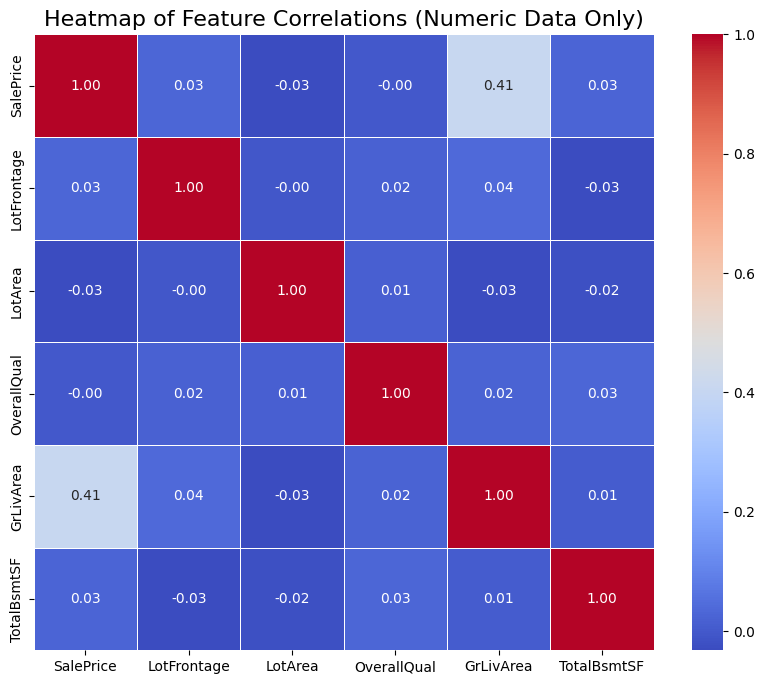

In [62]:
numeric_data = houses_data.select_dtypes(include=['float64', 'int64'])
correlation_matrix = numeric_data.corr()
# HeatMap Ploting
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap of Feature Correlations (Numeric Data Only)', fontsize=16)
plt.show()

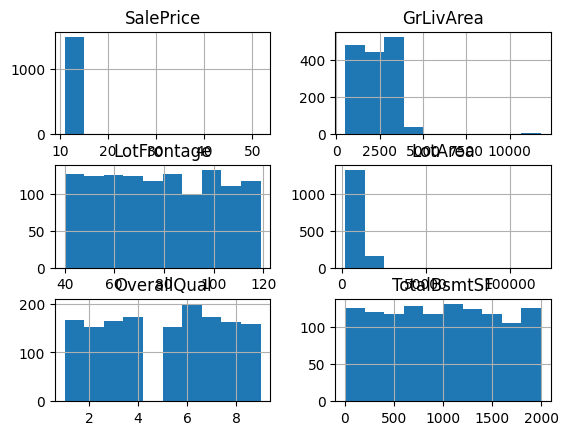

In [63]:
houses_data[['SalePrice','GrLivArea', 'LotFrontage', 'LotArea', 'OverallQual' , 'TotalBsmtSF']].hist()
plt.show()

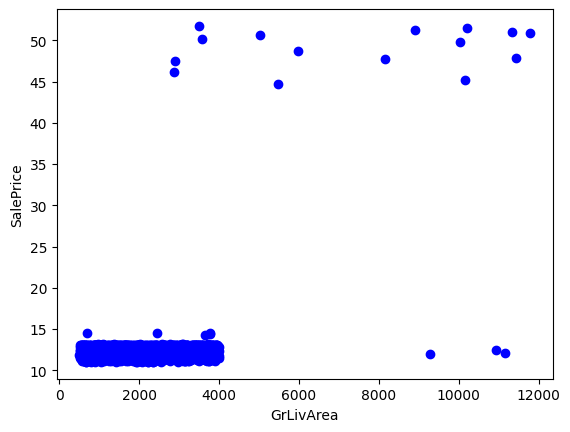

In [64]:
plt.scatter(houses_data.GrLivArea, houses_data.SalePrice,  color='blue')
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.show()

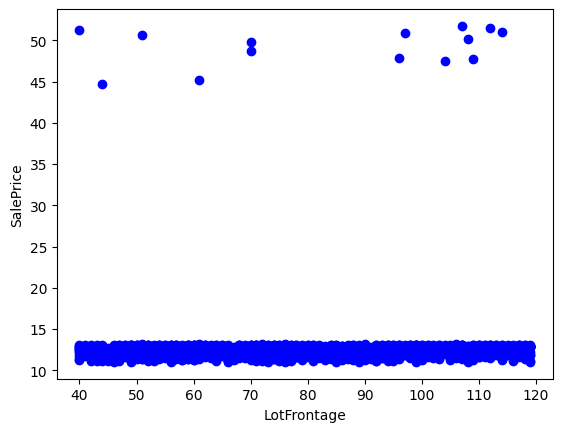

In [65]:
plt.scatter(houses_data.LotFrontage	, houses_data.SalePrice,  color='blue')
plt.xlabel("LotFrontage")
plt.ylabel("SalePrice")
plt.show()

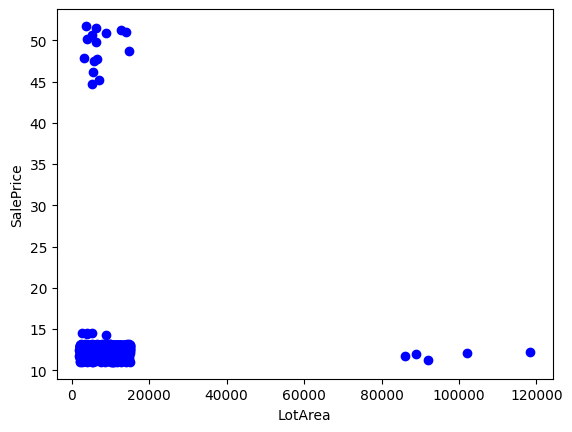

In [66]:
plt.scatter(houses_data.LotArea	, houses_data.SalePrice,  color='blue')
plt.xlabel("LotArea")
plt.ylabel("SalePrice")
plt.show()

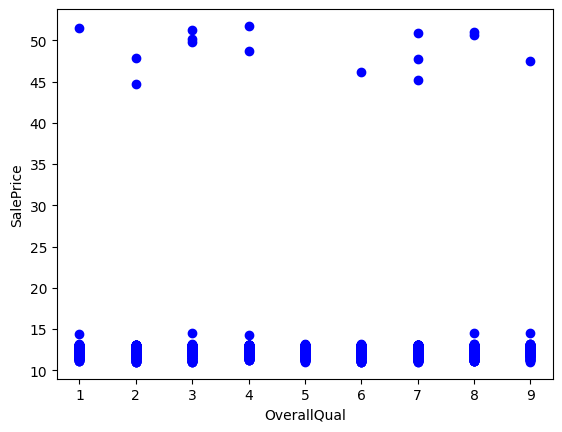

In [67]:
plt.scatter(houses_data.OverallQual	, houses_data.SalePrice,  color='blue')
plt.xlabel("OverallQual")
plt.ylabel("SalePrice")
plt.show()

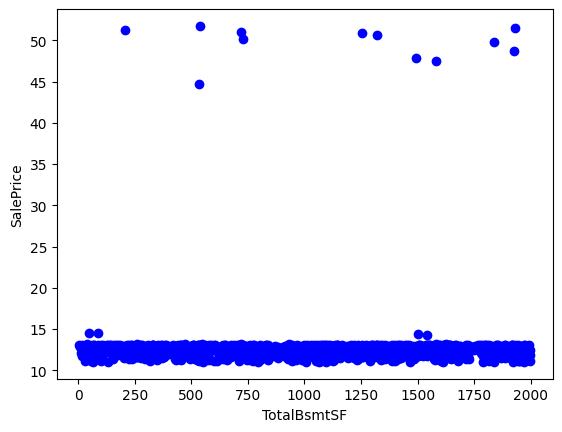

In [68]:
plt.scatter(houses_data.TotalBsmtSF	, houses_data.SalePrice,  color='blue')
plt.xlabel("TotalBsmtSF")
plt.ylabel("SalePrice")
plt.show()

# B-1
## Section B-1-2
### Remove Categorical columns

In [69]:
houses_data = houses_data.drop(columns=["HouseStyle", "CentralAir", "Neighborhood"])
print(houses_data.head())

   SalePrice  LotFrontage  LotArea  OverallQual  GrLivArea  TotalBsmtSF
0  14.467128          NaN     4044            3        690         87.0
1  14.467785          NaN     2557            8       3783         46.0
2  14.444119          NaN     3846            1       3777       1502.0
3  14.466687          NaN     5348            9       2444          NaN
4  14.322270          NaN     8980            4       3640       1542.0


In [70]:
houses_data.describe(include='all')

,SalePrice,LotFrontage,LotArea,OverallQual,GrLivArea,TotalBsmtSF
count,1500.000000,1211.000000,1500.000000,1500.000000,1500.00000,1207.000000
mean,12.769107,78.778695,8829.714000,5.028667,2343.65800,993.272577
std,3.690743,23.182508,6400.626065,2.549283,1243.16056,573.775186
min,11.004214,40.000000,2006.000000,1.000000,501.00000,5.000000
25%,12.055224,59.000000,5265.000000,3.000000,1397.75000,509.000000
50%,12.521724,78.000000,8491.500000,5.000000,2309.50000,998.000000
75%,12.886211,99.000000,12007.750000,7.000000,3212.25000,1488.000000
max,51.749346,119.000000,118429.000000,9.000000,11796.00000,1999.000000


## Remove NaN Values

In [71]:
houses_data = houses_data.dropna(subset=["LotFrontage", "TotalBsmtSF"])
print(houses_data.head())

     SalePrice  LotFrontage  LotArea  OverallQual  GrLivArea  TotalBsmtSF
226  13.105695        102.0    11784            9       1604       1221.0
227  12.871201         79.0     5200            3       3682       1676.0
228  12.699109         99.0     9239            6       3469       1766.0
230  12.682270         75.0     5326            6       1029        557.0
232  13.002302        109.0     3378            9       3926        560.0


In [72]:
houses_data.describe(include='all')

,SalePrice,LotFrontage,LotArea,OverallQual,GrLivArea,TotalBsmtSF
count,980.000000,980.000000,980.000000,980.000000,980.000000,980.000000
mean,12.856912,78.547959,8647.265306,4.932653,2357.581633,999.680612
std,4.139627,23.116633,4604.865218,2.526581,1310.331735,573.476062
min,11.004214,40.000000,2006.000000,1.000000,504.000000,6.000000
25%,12.090955,58.750000,5322.750000,3.000000,1393.750000,509.500000
50%,12.522178,78.000000,8457.500000,5.000000,2281.000000,994.000000
75%,12.880297,98.000000,11947.750000,7.000000,3215.250000,1501.000000
max,51.749346,119.000000,92109.000000,9.000000,11796.000000,1999.000000


## Section B-1-3
### Split Data

In [73]:
X = houses_data[['GrLivArea']]
y = houses_data["SalePrice"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(X_train.shape, X_test.shape)

(735, 1) (245, 1)


## Section B-1-4
### Linear & Multiple-Linear Regression

Coefficients:  [0.00104701]
Intercept:  10.34088087717167


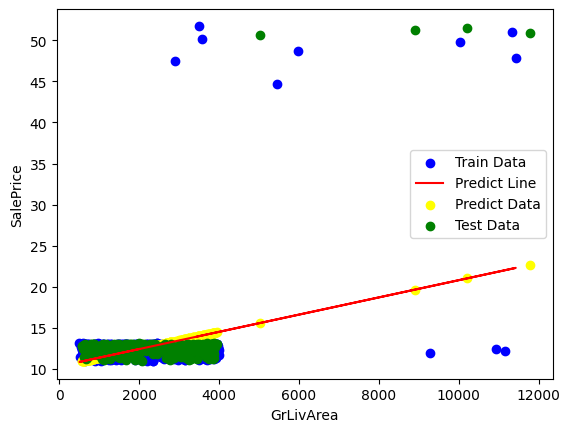

Linear Regression
MSE: 17.63792164293922


In [74]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred_lin = lin_reg.predict(X_test)
print ('Coefficients: ', lin_reg.coef_)
print ('Intercept: ', lin_reg.intercept_)
plt.scatter(X_train, y_train,  color='blue', label = 'Train Data')
plt.plot(X_train, lin_reg.coef_[0]*X_train + lin_reg.intercept_, '-r' , label = 'Predict Line')
plt.scatter(X_test, y_pred_lin,  color='yellow' , label = 'Predict Data')
plt.scatter(X_test, y_test,  color='green', label = 'Test Data')
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.legend()
plt.show()

mse_lin = mean_squared_error(y_test, y_pred_lin)

print("Linear Regression")
print("MSE:", mse_lin)

## Polynomial Regression

Polynomial Regression (degree=6)
MSE: 9.526861981674523


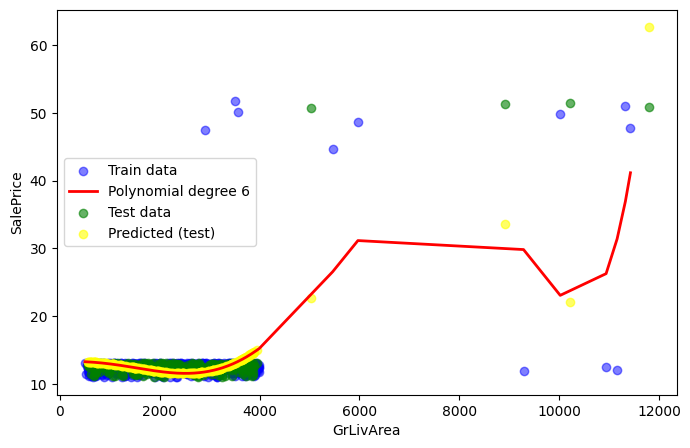

In [86]:
poly = PolynomialFeatures(degree=6, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
poly_reg = LinearRegression()
poly_reg.fit(X_train_poly, y_train)
y_pred_poly = poly_reg.predict(X_test_poly)

mse_poly = mean_squared_error(y_test, y_pred_poly)

print("Polynomial Regression (degree=6)")
print("MSE:", mse_poly)

X_plot = X_train.sort_values(by="GrLivArea")
X_plot_poly = poly.transform(X_plot)
y_plot = poly_reg.predict(X_plot_poly)

plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, color='blue', alpha=0.5, label="Train data")
plt.plot(X_plot, y_plot, color='red', linewidth=2, label="Polynomial degree 6")
plt.scatter(X_test, y_test, color='green', alpha=0.6, label="Test data")
plt.scatter(X_test, y_pred_poly, color='yellow', alpha=0.6, label="Predicted (test)")
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.legend()
plt.show()

## Multiple Linear Regression

In [87]:
msk = np.random.rand(len(houses_data)) < 0.75
train = houses_data[msk]
test = houses_data[~msk]

In [89]:
features = ['GrLivArea','TotalBsmtSF','OverallQual', 'LotArea', 'LotFrontage']
X_train_ML = train[features]
y_train_ML = train['SalePrice']
X_test_ML = test[features]
y_test_ML = test['SalePrice']
MLregr = LinearRegression()
MLregr.fit(X_train_ML, y_train_ML)
# The coefficients
print ('Coefficients: ', MLregr.coef_)
print ('Intercept: ' , MLregr.intercept_)
y_hat = MLregr.predict(X_test_ML)
mse_MLR = mean_squared_error(y_test_ML, y_hat)
print("MSE:", mse_MLR)

Coefficients:  [ 1.35116871e-03  2.37821013e-04 -4.31840033e-02 -1.53136600e-06
 -7.79589934e-04]
Intercept:  9.645983787892682
MSE: 17.442936038252917


## B-1-5 Mse
#### MSE of linear regression = 17.63792164293922
#### MSE of Polynomial regression = 9.526861981674523
#### MSE of Multiple linear regression = 17.442936038252917

# B-2

## Load Again The Dataset(previously has been changed)

In [3]:
file_path = "ames_housing.csv" 
houses_data_B = pd.read_csv(file_path)
houses_data_B.describe(include = 'all') 

,SalePrice,LotFrontage,LotArea,OverallQual,GrLivArea,TotalBsmtSF,HouseStyle,CentralAir,Neighborhood
count,1500.000000,1211.000000,1500.000000,1500.000000,1500.00000,1207.000000,1212,1500,1275
unique,NaN,NaN,NaN,NaN,NaN,NaN,4,2,5
top,NaN,NaN,NaN,NaN,NaN,NaN,SLvl,Y,Somerst
freq,NaN,NaN,NaN,NaN,NaN,NaN,305,771,274
mean,12.769107,78.778695,8829.714000,5.028667,2343.65800,993.272577,NaN,NaN,NaN
std,3.690743,23.182508,6400.626065,2.549283,1243.16056,573.775186,NaN,NaN,NaN
min,11.004214,40.000000,2006.000000,1.000000,501.00000,5.000000,NaN,NaN,NaN
25%,12.055224,59.000000,5265.000000,3.000000,1397.75000,509.000000,NaN,NaN,NaN
50%,12.521724,78.000000,8491.500000,5.000000,2309.50000,998.000000,NaN,NaN,NaN
75%,12.886211,99.000000,12007.750000,7.000000,3212.25000,1488.000000,NaN,NaN,NaN


## Section B-2-1

In [4]:
num_cols = [
    'LotArea', 'LotFrontage', 'GrLivArea',
    'TotalBsmtSF', 'OverallQual', 'SalePrice'
]

str_cols = [
    'Neighborhood', 'HouseStyle', 'CentralAir'
]

houses_data_B[num_cols] = houses_data_B[num_cols].fillna(houses_data_B[num_cols].mean())
for _ in str_cols:
    houses_data_B[_] = houses_data_B[_].fillna(houses_data_B[_].mode()[0])
# Check null value in every clomuns
houses_data_B[num_cols + str_cols].isnull().sum()
houses_data_B.describe(include = 'all')

,SalePrice,LotFrontage,LotArea,OverallQual,GrLivArea,TotalBsmtSF,HouseStyle,CentralAir,Neighborhood
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.00000,1500.000000,1500,1500,1500
unique,NaN,NaN,NaN,NaN,NaN,NaN,4,2,5
top,NaN,NaN,NaN,NaN,NaN,NaN,SLvl,Y,Somerst
freq,NaN,NaN,NaN,NaN,NaN,NaN,593,771,499
mean,12.769107,78.778695,8829.714000,5.028667,2343.65800,993.272577,NaN,NaN,NaN
std,3.690743,20.828226,6400.626065,2.549283,1243.16056,514.653109,NaN,NaN,NaN
min,11.004214,40.000000,2006.000000,1.000000,501.00000,5.000000,NaN,NaN,NaN
25%,12.055224,63.000000,5265.000000,3.000000,1397.75000,627.750000,NaN,NaN,NaN
50%,12.521724,78.778695,8491.500000,5.000000,2309.50000,993.272577,NaN,NaN,NaN
75%,12.886211,94.250000,12007.750000,7.000000,3212.25000,1356.250000,NaN,NaN,NaN


## Section B-2-2

In [5]:
Features  = [
    'LotArea', 'LotFrontage', 'GrLivArea',
    'TotalBsmtSF', 'OverallQual'
]
Q1 = houses_data_B[Features].quantile(0.25)
Q3 = houses_data_B[Features].quantile(0.75)
IQR = Q3 - Q1

mask = ~(
    (houses_data_B[Features] < (Q1 - 1.5 * IQR)) |
    (houses_data_B[Features] > (Q3 + 1.5 * IQR))
).any(axis=1)

houses_data_B.drop(houses_data_B.index[~mask], inplace=True)
houses_data_B.reset_index(drop=True, inplace=True)
houses_data_B.describe(include = 'all')

,SalePrice,LotFrontage,LotArea,OverallQual,GrLivArea,TotalBsmtSF,HouseStyle,CentralAir,Neighborhood
count,1483.000000,1483.000000,1483.000000,1483.000000,1483.000000,1483.000000,1483,1483,1483
unique,NaN,NaN,NaN,NaN,NaN,NaN,4,2,5
top,NaN,NaN,NaN,NaN,NaN,NaN,SLvl,Y,Somerst
freq,NaN,NaN,NaN,NaN,NaN,NaN,586,763,487
mean,12.551588,78.692693,8534.000674,5.025624,2282.633176,992.383346,NaN,NaN,NaN
std,2.365308,20.781104,3776.035338,2.549778,1033.808652,514.678600,NaN,NaN,NaN
min,11.004214,40.000000,2006.000000,1.000000,501.000000,5.000000,NaN,NaN,NaN
25%,12.053908,63.000000,5256.000000,3.000000,1390.500000,622.000000,NaN,NaN,NaN
50%,12.521529,78.778695,8469.000000,5.000000,2286.000000,993.272577,NaN,NaN,NaN
75%,12.880135,94.000000,11970.500000,7.000000,3204.500000,1356.500000,NaN,NaN,NaN


## Section B-2-3

In [6]:
houses_data_B_Dummies = pd.get_dummies(houses_data_B, columns=str_cols, drop_first=True)
houses_data_B_Dummies = houses_data_B_Dummies.astype(int) # Convert True , false to 1 , 0
houses_data_B_Dummies.describe(include ="all")

,SalePrice,LotFrontage,LotArea,OverallQual,GrLivArea,TotalBsmtSF,Neighborhood_Edwards,Neighborhood_NAmes,Neighborhood_OldTown,Neighborhood_Somerst,HouseStyle_1Story,HouseStyle_2Story,HouseStyle_SLvl,CentralAir_Y
count,1483.000000,1483.000000,1483.000000,1483.000000,1483.000000,1483.000000,1483.000000,1483.000000,1483.000000,1483.000000,1483.000000,1483.000000,1483.000000,1483.000000
mean,12.051922,78.541470,8534.000674,5.025624,2282.633176,992.330411,0.165206,0.167903,0.173297,0.328388,0.198921,0.202293,0.395145,0.514498
std,2.373237,20.782762,3776.035338,2.549778,1033.808652,514.678520,0.371491,0.373906,0.378632,0.469785,0.399323,0.401845,0.489047,0.499958
min,11.000000,40.000000,2006.000000,1.000000,501.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,12.000000,63.000000,5256.000000,3.000000,1390.500000,622.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,12.000000,78.000000,8469.000000,5.000000,2286.000000,993.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,12.000000,94.000000,11970.500000,7.000000,3204.500000,1356.500000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,51.000000,119.000000,14996.000000,9.000000,5463.000000,1999.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Section B-2-4

#### first split then scaler

In [7]:
X_P = houses_data_B_Dummies.drop('SalePrice', axis=1)
y_P = houses_data_B_Dummies['SalePrice']
X_train_P, X_test_P, y_train_P, y_test_P = train_test_split(X_P, y_P, test_size=0.25, random_state=42)

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_P)
X_test_scaled = scaler.transform(X_test_P)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train_P.columns, index=X_train_P.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test_P.columns, index=X_test_P.index)

## Section B-2-5
### Simple Linear Regression

Coefficients:  [0.2881805]
Intercept:  12.075539568345324


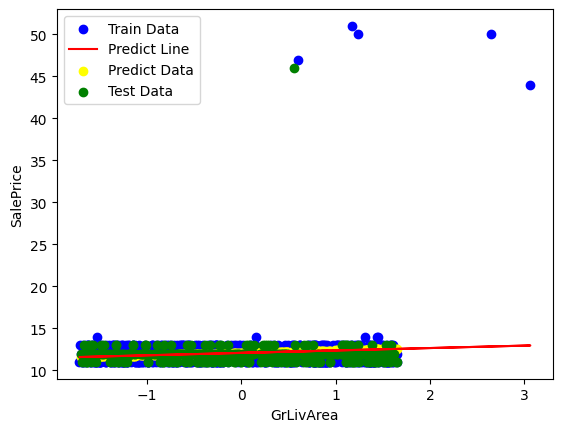

Linear Regression
MSE: 3.5426648963194687


In [9]:
linear_reg = LinearRegression()
linear_reg.fit(X_train_scaled[['GrLivArea']], y_train_P)
y_predicted_lin = linear_reg.predict(X_test_scaled[['GrLivArea']])
print ('Coefficients: ', linear_reg.coef_)
print ('Intercept: ', linear_reg.intercept_)

plt.scatter(X_train_scaled[['GrLivArea']] , y_train_P,  color='blue', label = 'Train Data')
plt.plot(X_train_scaled[['GrLivArea']], linear_reg.coef_[0]* X_train_scaled[['GrLivArea']] + linear_reg.intercept_, '-r' , label = 'Predict Line')
plt.scatter(X_test_scaled[['GrLivArea']], y_predicted_lin,  color='yellow' , label = 'Predict Data')
plt.scatter(X_test_scaled[['GrLivArea']], y_test_P,  color='green', label = 'Test Data')
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.legend()
plt.show()

mse_linear = mean_squared_error(y_test_P, y_predicted_lin)
print("Linear Regression")
print("MSE:", mse_linear)

## Polynomial Regresion

Polynomial Regression (degree=4)
MSE: 3.6369421264742767


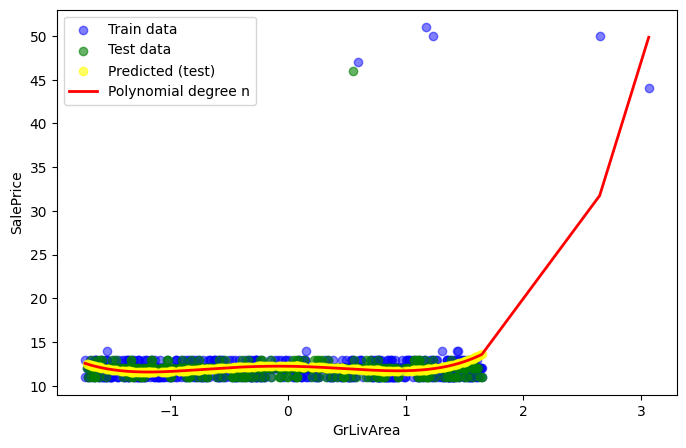

In [11]:
poly_P = PolynomialFeatures(degree= 4, include_bias=False)

X_train_poly_P = poly_P.fit_transform(X_train_scaled[['GrLivArea']])
X_test_poly_P = poly_P.transform(X_test_scaled[['GrLivArea']])

poly_reg_P = LinearRegression()
poly_reg_P.fit(X_train_poly_P, y_train_P)

y_pred_poly_P = poly_reg_P.predict(X_test_poly_P)

mse_poly_P = mean_squared_error(y_test_P, y_pred_poly_P)

print("Polynomial Regression (degree=4)")
print("MSE:", mse_poly_P)

X_plot_P = X_train_scaled.sort_values(by="GrLivArea")
X_plot_poly_P = poly_P.transform(X_plot_P[['GrLivArea']])
y_plot_P = poly_reg_P.predict(X_plot_poly_P)

plt.figure(figsize=(8, 5))
plt.scatter(X_train_scaled['GrLivArea'], y_train_P, color='blue', alpha=0.5, label="Train data")
plt.scatter(X_test_scaled['GrLivArea'], y_test_P, color='green', alpha=0.6, label="Test data")
plt.scatter(X_test_scaled['GrLivArea'], y_pred_poly_P, color='yellow', alpha=0.6, label="Predicted (test)")
plt.plot(X_plot_P['GrLivArea'], y_plot_P, color='red', linewidth=2, label="Polynomial degree n")
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.legend()
plt.show()

## Multiple Linear Regression

In [14]:
features = ['GrLivArea', 'TotalBsmtSF', 'OverallQual', 'LotArea', 'LotFrontage']
X_train_multi = X_train_scaled[features]
X_test_multi = X_test_scaled[features]
multi_reg = LinearRegression()
multi_reg.fit(X_train_multi, y_train_P)
y_pred_multi = multi_reg.predict(X_test_multi)
mse_multi = mean_squared_error(y_test_P, y_pred_multi)
print("Multiple Linear Regression (Standardized Data)")
print("MSE:", mse_multi)
print("Coefficients:", multi_reg.coef_)
print("Intercept:", multi_reg.intercept_)

Multiple Linear Regression (Standardized Data)
MSE: 3.536238492260006
Coefficients: [ 0.28303639 -0.05919951 -0.0130066  -0.13285977  0.04560818]
Intercept: 12.075539568345324
